In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv(r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\data\processed\meps_2022_clean.csv')

# Filter to eligible adults only
eligible = df[df['received_any_preventive'].notna()].copy()

print("Eligible adults:", len(eligible))
print("Outcome distribution:")
print(eligible['received_any_preventive'].value_counts())

Eligible adults: 11274
Outcome distribution:
received_any_preventive
1.0    10258
0.0     1016
Name: count, dtype: int64


In [3]:
# Recreate age_group since it wasn't saved to the CSV
bins = [18, 35, 50, 65, 85]
labels = ['18–34', '35–49', '50–64', '65+']
eligible['age_group'] = pd.cut(eligible['AGE22X'], bins=bins,
                                labels=labels, right=True)

print("Age group counts:")
print(eligible['age_group'].value_counts().sort_index())

Age group counts:
age_group
18–34    2091
35–49    2267
50–64    3076
65+      3799
Name: count, dtype: int64


In [5]:
# Age group dummies — reference: 65+
eligible['age_18_34'] = (eligible['age_group'] == '18–34').astype(int)
eligible['age_35_49'] = (eligible['age_group'] == '35–49').astype(int)
eligible['age_50_64'] = (eligible['age_group'] == '50–64').astype(int)

# Income dummies — reference: High Income
eligible['inc_poor']     = (eligible['income_tier'] == 'Poor\n(<100% FPL)').astype(int)
eligible['inc_nearpoor'] = (eligible['income_tier'] == 'Near Poor\n(100-124%)').astype(int)
eligible['inc_low']      = (eligible['income_tier'] == 'Low Income\n(125-199%)').astype(int)
eligible['inc_middle']   = (eligible['income_tier'] == 'Middle Income\n(200-399%)').astype(int)

# Insurance dummies — reference: Private
eligible['ins_public']    = (eligible['insurance_cat'] == 'Public Only').astype(int)
eligible['ins_medicare']  = (eligible['insurance_cat'].isin(
    ['Medicare Only', 'Medicare + Private', 'Medicare + Public'])).astype(int)
eligible['ins_uninsured'] = (eligible['insurance_cat'] == 'Uninsured').astype(int)

# Race dummies — reference: NH White
eligible['race_black']    = (eligible['race_eth'] == 'NH Black').astype(int)
eligible['race_hispanic'] = (eligible['race_eth'] == 'Hispanic').astype(int)
eligible['race_asian']    = (eligible['race_eth'] == 'NH Asian').astype(int)
eligible['race_other']    = (eligible['race_eth'] == 'NH Other').astype(int)

# Sex — reference: Female
eligible['male'] = (eligible['SEX'] == 1).astype(int)

print("age_18_34 counts:", eligible['age_18_34'].value_counts().to_dict())
print("inc_poor counts:", eligible['inc_poor'].value_counts().to_dict())
print("race_black counts:", eligible['race_black'].value_counts().to_dict())
print("\nReady for modeling.")

age_18_34 counts: {0: 9183, 1: 2091}
inc_poor counts: {0: 9631, 1: 1643}
race_black counts: {0: 9778, 1: 1496}

Ready for modeling.


In [6]:
# Logistic regression
# Outcome: received_any_preventive (1=yes, 0=no)
# Predictors: age, income, insurance, race, sex

formula = """
received_any_preventive ~ 
    age_18_34 + age_35_49 + age_50_64 +
    inc_poor + inc_nearpoor + inc_low + inc_middle +
    ins_public + ins_medicare + ins_uninsured +
    race_black + race_hispanic + race_asian + race_other +
    male
"""

model = smf.logit(formula, data=eligible).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.244155
         Iterations 8
                              Logit Regression Results                             
Dep. Variable:     received_any_preventive   No. Observations:                11274
Model:                               Logit   Df Residuals:                    11258
Method:                                MLE   Df Model:                           15
Date:                     Mon, 25 May 2026   Pseudo R-squ.:                  0.1937
Time:                             20:51:18   Log-Likelihood:                -2752.6
converged:                            True   LL-Null:                       -3413.9
Covariance Type:                 nonrobust   LLR p-value:                7.273e-273
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         6.0171      0.154     39.178      0.000     

In [7]:
# Convert log-odds coefficients to odds ratios
# OR = e^coef, CI = e^[lower, upper]

import numpy as np

# Extract results
params = model.params
conf = model.conf_int()
conf.columns = ['ci_lower', 'ci_upper']

results = pd.DataFrame({
    'coef': params,
    'or': np.exp(params),
    'ci_lower': np.exp(conf['ci_lower']),
    'ci_upper': np.exp(conf['ci_upper']),
    'pvalue': model.pvalues
})

# Drop intercept
results = results.drop('Intercept')

# Add readable labels
labels = {
    'age_18_34':     'Age 18–34 vs 65+',
    'age_35_49':     'Age 35–49 vs 65+',
    'age_50_64':     'Age 50–64 vs 65+',
    'inc_poor':      'Poor vs High Income',
    'inc_nearpoor':  'Near Poor vs High Income',
    'inc_low':       'Low Income vs High Income',
    'inc_middle':    'Middle Income vs High Income',
    'ins_public':    'Public Only vs Private',
    'ins_medicare':  'Medicare vs Private',
    'ins_uninsured': 'Uninsured vs Private',
    'race_black':    'NH Black vs NH White',
    'race_hispanic': 'Hispanic vs NH White',
    'race_asian':    'NH Asian vs NH White',
    'race_other':    'NH Other vs NH White',
    'male':          'Male vs Female'
}
results['label'] = results.index.map(labels)
results['significant'] = results['pvalue'] < 0.05

print(results[['label', 'or', 'ci_lower', 'ci_upper', 'pvalue', 'significant']].round(3))

                                      label     or  ci_lower  ci_upper  \
age_18_34                  Age 18–34 vs 65+  0.047     0.036     0.062   
age_35_49                  Age 35–49 vs 65+  0.078     0.059     0.103   
age_50_64                  Age 50–64 vs 65+  0.180     0.136     0.238   
inc_poor                Poor vs High Income  0.340     0.268     0.431   
inc_nearpoor       Near Poor vs High Income  0.516     0.359     0.742   
inc_low           Low Income vs High Income  0.516     0.406     0.657   
inc_middle     Middle Income vs High Income  0.519     0.428     0.628   
ins_public           Public Only vs Private  0.926     0.750     1.142   
ins_medicare            Medicare vs Private  0.282     0.233     0.341   
ins_uninsured          Uninsured vs Private  0.181     0.081     0.407   
race_black             NH Black vs NH White  0.530     0.432     0.649   
race_hispanic          Hispanic vs NH White  0.467     0.391     0.557   
race_asian             NH Asian vs NH 

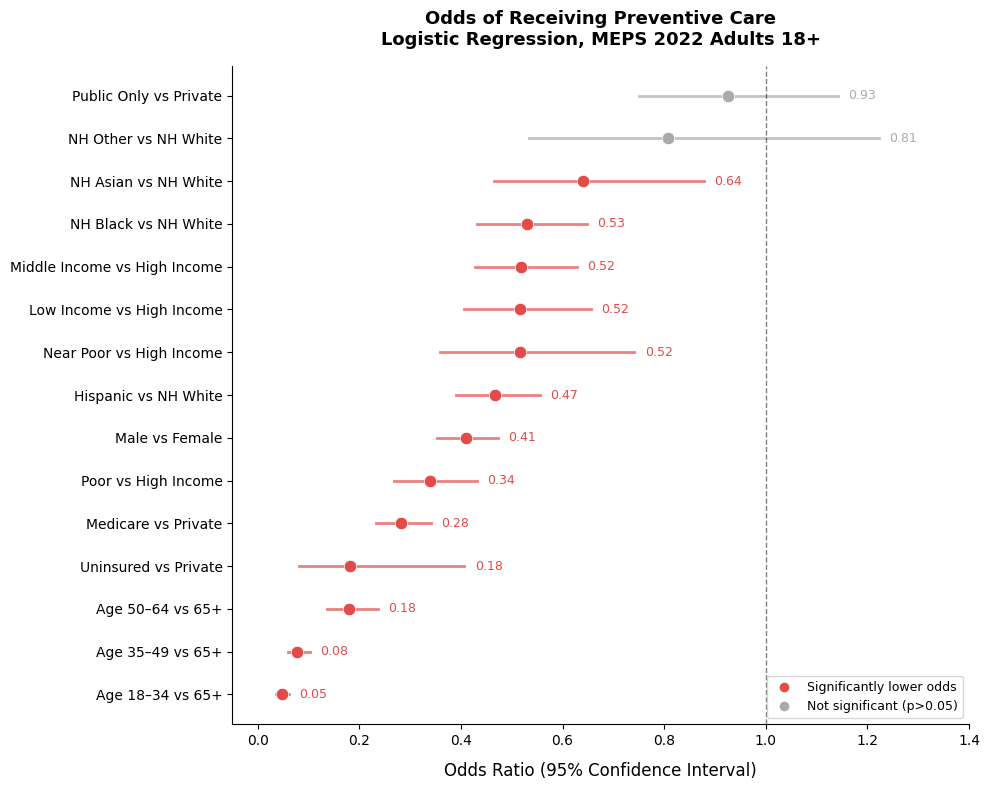

Saved.


In [8]:
# Visual 5: Forest plot — odds ratios with 95% confidence intervals
# Sort by OR for cleaner display, keep non-significant ones in gray

plot_df = results.copy().sort_values('or', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Colors: significant = blue/red, non-significant = gray
colors = []
for _, row in plot_df.iterrows():
    if not row['significant']:
        colors.append('#AAAAAA')
    elif row['or'] < 1:
        colors.append('#E24B4A')
    else:
        colors.append('#378ADD')

# Plot confidence interval lines
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['ci_lower'], row['ci_upper']], [i, i],
            color=colors[i], linewidth=2, alpha=0.7)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.scatter(row['or'], i,
               color=colors[i], s=80, zorder=5,
               edgecolors='white', linewidths=0.5)

ax.axvline(x=1, color='black', linestyle='--',
           linewidth=1, alpha=0.5)

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=10)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['ci_upper'] + 0.02, i,
            f"{row['or']:.2f}",
            va='center', fontsize=9,
            color=colors[i])

ax.set_xlabel('Odds Ratio (95% Confidence Interval)', fontsize=12, labelpad=10)
ax.set_title('Odds of Receiving Preventive Care\nLogistic Regression, MEPS 2022 Adults 18+',
             fontsize=13, fontweight='bold', pad=15)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E24B4A',
           markersize=8, label='Significantly lower odds'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#AAAAAA',
           markersize=8, label='Not significant (p>0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.05, 1.4)

plt.tight_layout()

output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig5_forest_plot.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Segment sizing using PERWT22F survey weights - how many Americans each group represents

# Define segments — combinations of high-risk factors
segments = []

# Age groups
for age_grp in ['18–34', '35–49', '50–64', '65+']:
    seg = eligible[eligible['age_group'] == age_grp]
    n_weighted = seg['PERWT22F'].sum()
    gap_rate = 1 - seg['received_any_preventive'].mean()
    segments.append({
        'segment': f'Age {age_grp}',
        'category': 'Age',
        'n_weighted': n_weighted,
        'gap_rate': gap_rate,
        'n_sample': len(seg)
    })

# Income groups
for inc, label in [(1,'Poor'), (2,'Near Poor'), 
                   (3,'Low Income'), (4,'Middle Income'), (5,'High Income')]:
    seg = eligible[eligible['POVCAT22'] == inc]
    n_weighted = seg['PERWT22F'].sum()
    gap_rate = 1 - seg['received_any_preventive'].mean()
    segments.append({
        'segment': label,
        'category': 'Income',
        'n_weighted': n_weighted,
        'gap_rate': gap_rate,
        'n_sample': len(seg)
    })

# Race groups
for race in ['NH White', 'NH Black', 'Hispanic', 'NH Asian']:
    seg = eligible[eligible['race_eth'] == race]
    n_weighted = seg['PERWT22F'].sum()
    gap_rate = 1 - seg['received_any_preventive'].mean()
    segments.append({
        'segment': race,
        'category': 'Race',
        'n_weighted': n_weighted,
        'gap_rate': gap_rate,
        'n_sample': len(seg)
    })

seg_df = pd.DataFrame(segments)
seg_df['n_millions'] = seg_df['n_weighted'] / 1_000_000
seg_df['gap_pct'] = seg_df['gap_rate'] * 100

print(seg_df[['segment', 'category', 'n_millions', 
              'gap_pct', 'n_sample']].round(2).to_string())

          segment category  n_millions  gap_pct  n_sample
0       Age 18–34      Age       39.45    20.95      2091
1       Age 35–49      Age       35.79    12.84      2267
2       Age 50–64      Age       40.44     6.34      3076
3         Age 65+      Age       41.59     2.16      3799
4            Poor   Income       15.75    14.61      1643
5       Near Poor   Income        5.70    10.60       500
6      Low Income   Income       18.53    11.27      1508
7   Middle Income   Income       45.27    11.00      3045
8     High Income   Income       72.72     4.76      4578
9        NH White     Race      103.86     5.33      7032
10       NH Black     Race       16.66    12.70      1496
11       Hispanic     Race       23.44    19.69      1864
12       NH Asian     Race        9.71     8.84       588


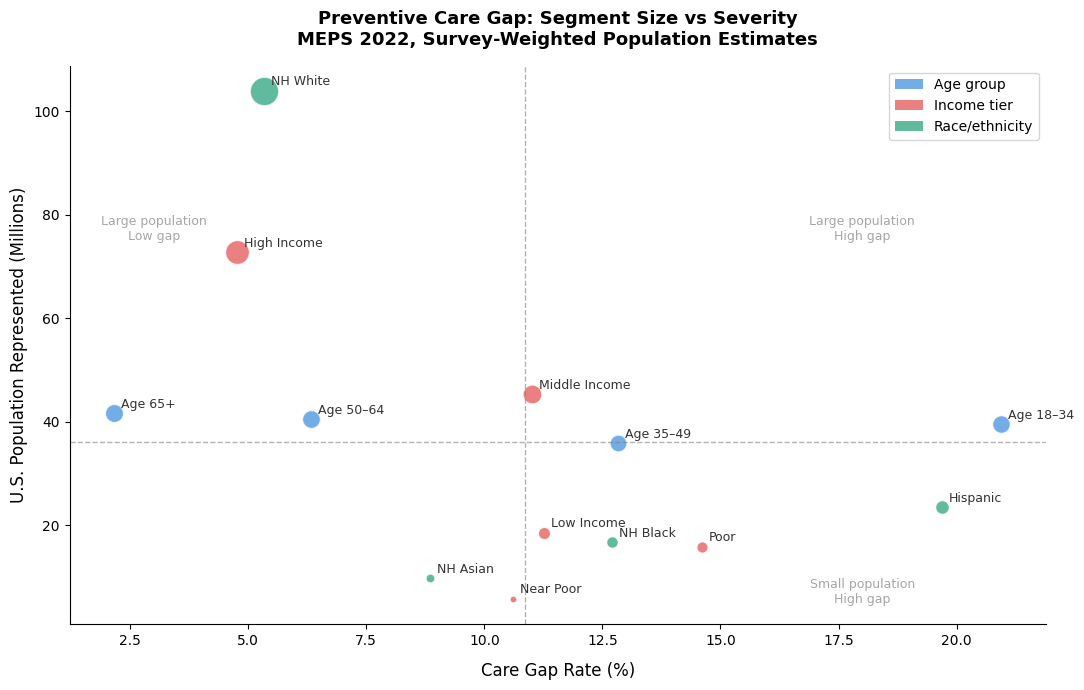

In [10]:
# Visual 6: Bubble chart — segment size vs care gap severity
# X axis: gap rate, Y axis: weighted population (millions)
# Bubble size: also encodes population size
# Color: category (age/income/race)

fig, ax = plt.subplots(figsize=(11, 7))

category_colors = {
    'Age':    '#378ADD',
    'Income': '#E24B4A',
    'Race':   '#1D9E75'
}

for _, row in seg_df.iterrows():
    color = category_colors[row['category']]
    ax.scatter(row['gap_pct'], row['n_millions'],
               s=row['n_millions'] * 4,
               color=color, alpha=0.7,
               edgecolors='white', linewidths=0.8)
    # Label each bubble
    ax.annotate(row['segment'],
                xy=(row['gap_pct'], row['n_millions']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=9, color='#333333')

# Reference lines
ax.axvline(x=seg_df['gap_pct'].mean(), color='gray',
           linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=seg_df['n_millions'].mean(), color='gray',
           linestyle='--', linewidth=1, alpha=0.6)

# Quadrant labels
ax.text(18, 75, 'Large population\nHigh gap',
        fontsize=9, color='gray', alpha=0.7, ha='center')
ax.text(3, 75, 'Large population\nLow gap',
        fontsize=9, color='gray', alpha=0.7, ha='center')
ax.text(18, 5, 'Small population\nHigh gap',
        fontsize=9, color='gray', alpha=0.7, ha='center')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#378ADD', alpha=0.7, label='Age group'),
    Patch(facecolor='#E24B4A', alpha=0.7, label='Income tier'),
    Patch(facecolor='#1D9E75', alpha=0.7, label='Race/ethnicity')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_xlabel('Care Gap Rate (%)', fontsize=12, labelpad=10)
ax.set_ylabel('U.S. Population Represented (Millions)', fontsize=12)
ax.set_title('Preventive Care Gap: Segment Size vs Severity\nMEPS 2022, Survey-Weighted Population Estimates',
             fontsize=13, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

output_path = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\figures\fig6_bubble_chart.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Scorecard table — top 3 at-risk segments
# Based on: gap rate, population size, and model odds ratios

scorecard_data = {
    'Segment': [
        'Young Adults (18–34)',
        'Hispanic Adults',
        'Poor Adults (<100% FPL)'
    ],
    'Care Gap Rate': [
        '20.9%',
        '19.7%',
        '14.6%'
    ],
    'Est. U.S. Population': [
        '39.4M',
        '23.4M',
        '15.8M'
    ],
    'Est. Adults Missing Care': [
        '~8.3M',
        '~4.6M',
        '~2.3M'
    ],
    'Odds Ratio vs Reference': [
        '0.05 vs Age 65+',
        '0.47 vs NH White',
        '0.34 vs High Income'
    ],
    'Top Barrier': [
        'Cost & no regular provider',
        'Language & cultural barriers',
        'Cost & limited coverage'
    ],
    'Recommended Intervention': [
        'Targeted outreach + telehealth preventive visits',
        'Culturally competent care + navigator programs',
        'Medicaid expansion + cost-sharing waivers'
    ]
}

scorecard_df = pd.DataFrame(scorecard_data)
print(scorecard_df.to_string())

                   Segment Care Gap Rate Est. U.S. Population Est. Adults Missing Care Odds Ratio vs Reference                   Top Barrier                          Recommended Intervention
0     Young Adults (18–34)         20.9%                39.4M                    ~8.3M         0.05 vs Age 65+    Cost & no regular provider  Targeted outreach + telehealth preventive visits
1          Hispanic Adults         19.7%                23.4M                    ~4.6M        0.47 vs NH White  Language & cultural barriers    Culturally competent care + navigator programs
2  Poor Adults (<100% FPL)         14.6%                15.8M                    ~2.3M     0.34 vs High Income       Cost & limited coverage         Medicaid expansion + cost-sharing waivers


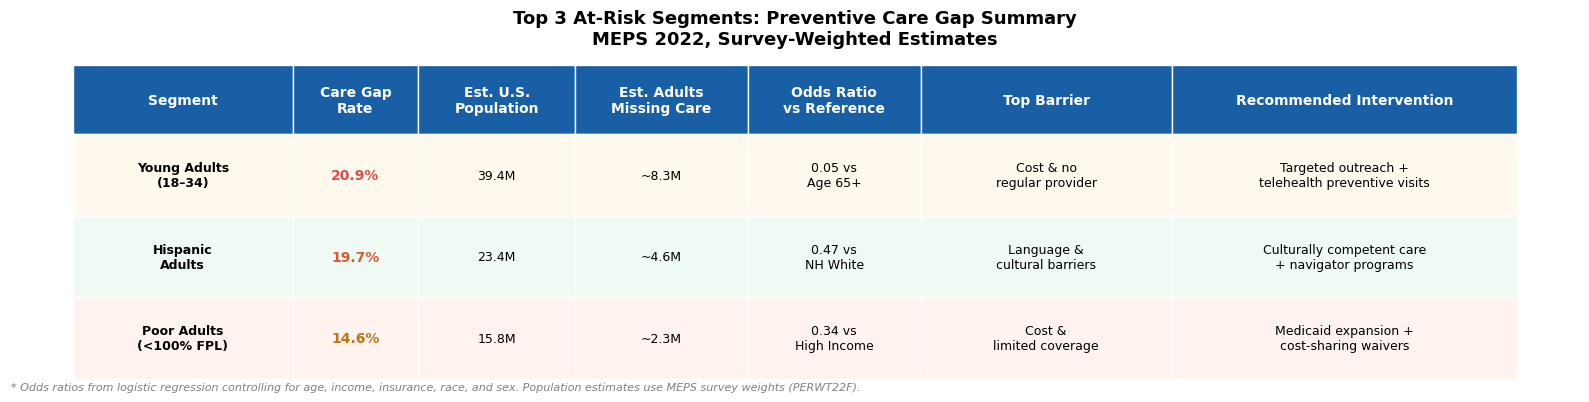

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')

# Table data
columns = [
    'Segment',
    'Care Gap\nRate',
    'Est. U.S.\nPopulation',
    'Est. Adults\nMissing Care',
    'Odds Ratio\nvs Reference',
    'Top Barrier',
    'Recommended Intervention'
]

rows = [
    ['Young Adults\n(18–34)', '20.9%', '39.4M', '~8.3M',
     '0.05 vs\nAge 65+',
     'Cost & no\nregular provider',
     'Targeted outreach +\ntelehealth preventive visits'],
    ['Hispanic\nAdults', '19.7%', '23.4M', '~4.6M',
     '0.47 vs\nNH White',
     'Language &\ncultural barriers',
     'Culturally competent care\n+ navigator programs'],
    ['Poor Adults\n(<100% FPL)', '14.6%', '15.8M', '~2.3M',
     '0.34 vs\nHigh Income',
     'Cost &\nlimited coverage',
     'Medicaid expansion +\ncost-sharing waivers'],
]

# Column widths (must sum to 1)
col_widths = [0.14, 0.08, 0.10, 0.11, 0.11, 0.16, 0.22]

# Header row
header_colors = ['#185FA5'] * len(columns)
row_colors = [
    ['#FAEEDA', '#FAEEDA', '#FAEEDA', '#FAEEDA',
     '#FAEEDA', '#FAEEDA', '#FAEEDA'],
    ['#E1F5EE', '#E1F5EE', '#E1F5EE', '#E1F5EE',
     '#E1F5EE', '#E1F5EE', '#E1F5EE'],
    ['#FAECE7', '#FAECE7', '#FAECE7', '#FAECE7',
     '#FAECE7', '#FAECE7', '#FAECE7'],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

# Style header
for j in range(len(columns)):
    cell = table[0, j]
    cell.set_facecolor('#185FA5')
    cell.set_text_props(color='white', fontsize=10, fontweight='bold')
    cell.set_edgecolor('white')
    cell.set_height(0.22)

# Style data rows
row_bg = ['#FFF8EC', '#F0FAF5', '#FEF3EE']
for i in range(len(rows)):
    for j in range(len(columns)):
        cell = table[i+1, j]
        cell.set_facecolor(row_bg[i])
        cell.set_edgecolor('white')
        cell.set_text_props(fontsize=9)
        cell.set_height(0.26)

# Bold the segment column
for i in range(len(rows)):
    table[i+1, 0].set_text_props(fontsize=9, fontweight='bold')

# Bold and color the gap rate column
gap_colors = ['#E24B4A', '#D85A30', '#BA7517']
for i in range(len(rows)):
    table[i+1, 1].set_text_props(fontsize=10, fontweight='bold',
                                   color=gap_colors[i])

table.auto_set_font_size(False)
table.scale(1, 1)

ax.set_title('Top 3 At-Risk Segments: Preventive Care Gap Summary\nMEPS 2022, Survey-Weighted Estimates',
             fontsize=13, fontweight='bold', pad=20, y=0.98)

# Footnote
fig.text(0.01, 0.01,
         '* Odds ratios from logistic regression controlling for age, income, insurance, race, and sex. '
         'Population estimates use MEPS survey weights (PERWT22F).',
         fontsize=8, color='gray', style='italic')

plt.tight_layout()

# Save PNG
output_png = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\tables\fig7_scorecard.png'
plt.savefig(output_png, dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

# Save CSV
output_csv = r'C:\Users\anikh\OneDrive\Desktop\preventive-care-gaps\outputs\tables\scorecard.csv'
scorecard_df.to_csv(output_csv, index=False)